<a href="https://colab.research.google.com/github/ngkhanhly3103/Emotion-Recognition/blob/master/MLPFace_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CONFIG = {
    'csv_path': '/content/drive/MyDrive/AFFEC/results_felt_new/FAU_All_Subjects_Final(Felt emotion).csv', # Sửa lại đường dẫn của bạn
    'save_path': '/content/drive/MyDrive/AFFEC/results_felt_new/best_fau_model_fusion_independent_new.pth',
    'output_dir': '/content/drive/MyDrive/AFFEC/results_felt_new/comparison_analysis',
    'batch_size': 64,
    'learning_rate': 0.001,
    'epochs': 80,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # Các cột đặc trưng đầu vào (Input Features) - Chọn các cột đã chuẩn hóa (_norm)
    'feature_cols': [
        'AU01_r_norm', 'AU02_r_norm', 'AU04_r_norm', 'AU05_r_norm', 'AU06_r_norm',
        'AU07_r_norm', 'AU09_r_norm', 'AU10_r_norm', 'AU12_r_norm', 'AU14_r_norm',
        'AU15_r_norm', 'AU17_r_norm', 'AU20_r_norm', 'AU23_r_norm', 'AU25_r_norm',
        'AU26_r_norm', 'AU45_r_norm'],
    'target_col': 'Label', # Cột nhãn cảm xúc thực tế
    'subject_col': 'Subject'
}

⏳ Đang đọc dữ liệu từ: /content/drive/MyDrive/AFFEC/results_felt_new/FAU_All_Subjects_Final(Felt emotion).csv

THỐNG KÊ SỐ LƯỢNG NHÃN:
Label
HAHV    17344
HALV    29684
LAHV    25939
LALV    23968
Name: count, dtype: int64

--- Correlation Analysis ---
Correlation Valence (Face vs Felt): r=0.033, p=2.614e-24
Correlation Arousal (Face vs Felt): r=0.038, p=1.144e-32


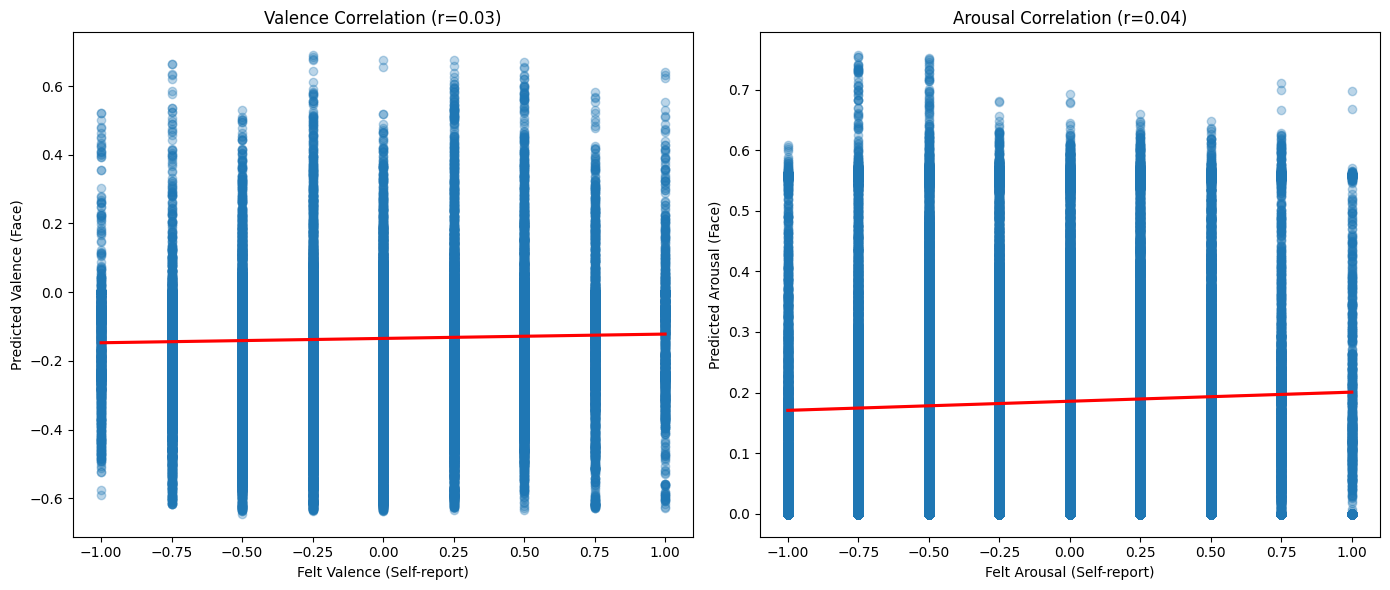


--- Classification Analysis ---


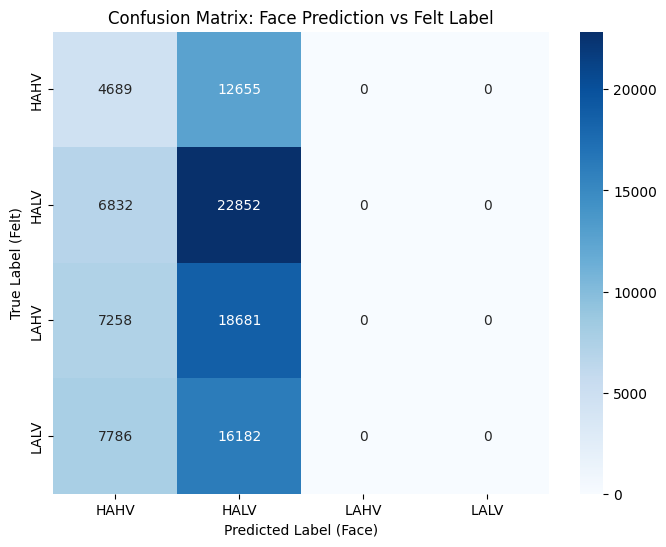

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-1371983196.py:96: FutureWarnin

              precision    recall  f1-score   support

        HAHV       0.18      0.27      0.21     17344
        HALV       0.32      0.77      0.46     29684
        LAHV       0.00      0.00      0.00     25939
        LALV       0.00      0.00      0.00     23968

    accuracy                           0.28     96935
   macro avg       0.13      0.26      0.17     96935
weighted avg       0.13      0.28      0.18     96935


--- Distribution Comparison ---


/tmp/ipython-input-1371983196.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


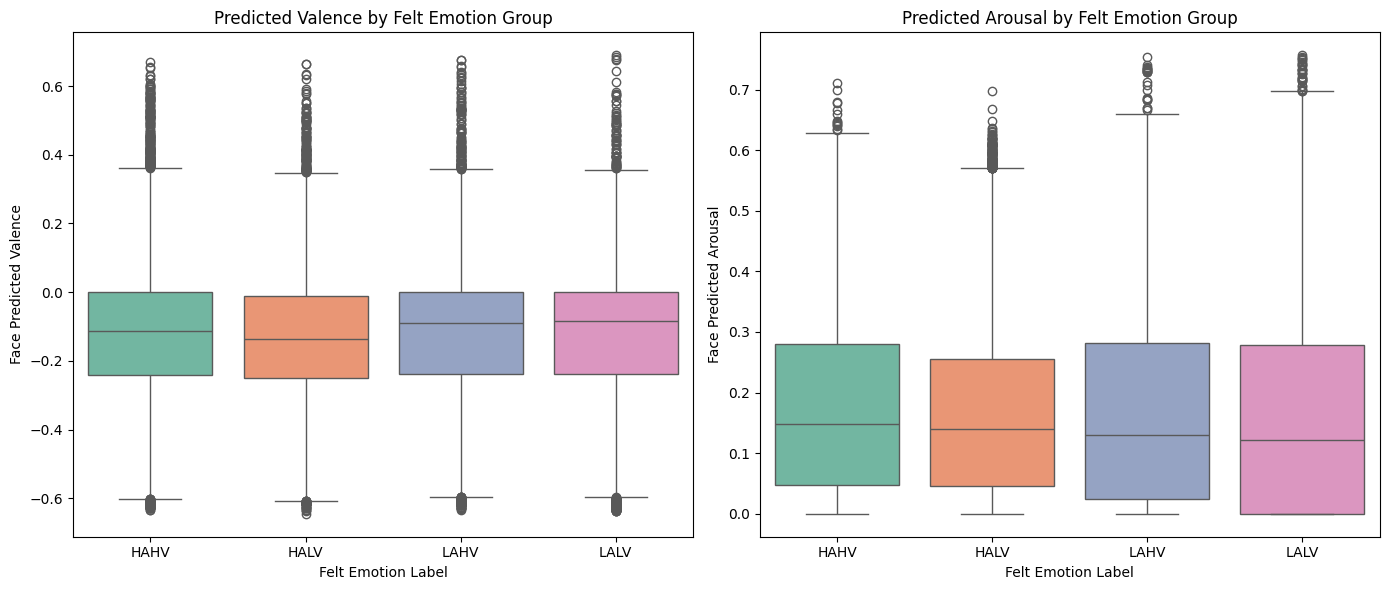

In [ ]:
print(f"⏳ Đang đọc dữ liệu từ: {CONFIG['csv_path']}")

if not os.path.exists(CONFIG['output_dir']):
    os.makedirs(CONFIG['output_dir'])

if os.path.exists(CONFIG['csv_path']):
    df = pd.read_csv(CONFIG['csv_path'])

    # 1. Lọc nhãn hợp lệ
    # Chỉ lấy 4 nhãn chính, bỏ Unknown/Missing
    valid_labels = ['HAHV', 'HALV', 'LAHV', 'LALV']
    df_clean = df[df['Label'].isin(valid_labels)]

    y = df_clean['Label'].values
    classes = np.unique(y)

    # 2. Thống kê số lượng
    print("\nTHỐNG KÊ SỐ LƯỢNG NHÃN:")
    counts = df_clean['Label'].value_counts().sort_index()
    print(counts)

    # --- PHÂN TÍCH TƯƠNG QUAN (CORRELATION) ---
    print("\n--- Correlation Analysis ---")

    # Valence
    corr_v, p_v = pearsonr(df_clean['Valence_Pred'], df_clean['User_Rating_V'])
    print(f"Correlation Valence (Face vs Felt): r={corr_v:.3f}, p={p_v:.3e}")

    # Arousal
    corr_a, p_a = pearsonr(df_clean['Arousal_Pred'], df_clean['User_Rating_A'])
    print(f"Correlation Arousal (Face vs Felt): r={corr_a:.3f}, p={p_a:.3e}")

    # Vẽ Scatter Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Valence Plot
    sns.regplot(x='User_Rating_V', y='Valence_Pred', data=df_clean, ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[0].set_title(f'Valence Correlation (r={corr_v:.2f})')
    axes[0].set_xlabel('Felt Valence (Self-report)')
    axes[0].set_ylabel('Predicted Valence (Face)')

    # Arousal Plot
    sns.regplot(x='User_Rating_A', y='Arousal_Pred', data=df_clean, ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[1].set_title(f'Arousal Correlation (r={corr_a:.2f})')
    axes[1].set_xlabel('Felt Arousal (Self-report)')
    axes[1].set_ylabel('Predicted Arousal (Face)')

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'correlation_plot.png'))
    plt.show()

    # --- SO SÁNH PHÂN LOẠI (CLASSIFICATION) ---
    print("\n--- Classification Analysis ---")

    # Chúng ta cần chuyển 'Dominant_Pred' hoặc mapping lại Valence/Arousal dự đoán sang Label (HAHV, HALV...) để so sánh với 'Label' gốc
    # Ở đây ta dùng lại logic mapping trong code xử lý để tạo nhãn dự đoán từ Valence_Pred và Arousal_Pred

    def map_pred_to_label(row):
        v = row['Valence_Pred']
        a = row['Arousal_Pred']
        # Ngưỡng phân loại (Threshold). Vì Valence/Arousal dự đoán nằm trong khoảng [-1, 1], ngưỡng là 0.
        threshold = 0
        if a >= threshold and v >= threshold: return 'HAHV'
        if a >= threshold and v < threshold: return 'HALV'
        if a < threshold and v >= threshold: return 'LAHV'
        return 'LALV'

    df_clean['Predicted_Label_From_VA'] = df_clean.apply(map_pred_to_label, axis=1)

    # Confusion Matrix
    labels = ['HAHV', 'HALV', 'LAHV', 'LALV']
    cm = confusion_matrix(df_clean['Label'], df_clean['Predicted_Label_From_VA'], labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix: Face Prediction vs Felt Label')
    plt.xlabel('Predicted Label (Face)')
    plt.ylabel('True Label (Felt)')
    plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrix.png'))
    plt.show()

    print(classification_report(df_clean['Label'], df_clean['Predicted_Label_From_VA'], target_names=labels))

    # --- SO SÁNH PHÂN PHỐI (BOXPLOT) ---
    print("\n--- Distribution Comparison ---")

    # Chuẩn bị dữ liệu để vẽ
    # Chúng ta cần chuẩn hóa thang đo để so sánh (vì User Rating có thể là 1-9 còn Pred là -1 đến 1)
    # Cách đơn giản là scale User Rating về -1 đến 1 hoặc ngược lại. Hoặc vẽ 2 trục y khác nhau.
    # Ở đây vẽ đơn giản trên 2 biểu đồ riêng biệt hoặc chuẩn hóa MinMax về 0-1 để so sánh hình dáng phân phối.

    # Vẽ phân phối Valence theo từng nhóm nhãn thực tế
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot Valence
    sns.boxplot(
    x='Label',
    y='Valence_Pred',
    data=df_clean,
    order=labels,
    ax=axes[0],
    palette='Set2'
    )
    axes[0].set_title('Predicted Valence by Felt Emotion Group')
    axes[0].set_xlabel('Felt Emotion Label')
    axes[0].set_ylabel('Face Predicted Valence')

# Boxplot Arousal
    sns.boxplot(
    x='Label',
    y='Arousal_Pred',
    data=df_clean,
    order=labels,
    ax=axes[1],
    palette='Set2')
    axes[1].set_title('Predicted Arousal by Felt Emotion Group')
    axes[1].set_xlabel('Felt Emotion Label')
    axes[1].set_ylabel('Face Predicted Arousal')

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'valence_arousal_distribution.png'))
    plt.show()


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Thêm cấu hình tên cột chứa ID người dùng (trong file CSV của bạn)
CONFIG['subject_col'] = 'Subject' # Hoặc 'Subject', 'Participant'... tùy file CSV

class FAUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def FAU_independent_split():

    print(f"Đang đọc dữ liệu từ: {CONFIG['csv_path']}")

    if not os.path.exists(CONFIG['csv_path']):
        raise FileNotFoundError("Không tìm thấy file CSV! Hãy kiểm tra lại đường dẫn.")

    df = pd.read_csv(CONFIG['csv_path'])

    # 1. Tiền xử lý cơ bản (Lọc Unknown/Missing)
    df = df[df[CONFIG['target_col']] != 'Unknown']
    df = df.dropna(subset=CONFIG['feature_cols'] + [CONFIG['target_col']])

    # Đảm bảo cột Subject là string để so sánh
    df[CONFIG['subject_col']] = df[CONFIG['subject_col']].astype(str).str.strip()

    # 2. Mã hóa nhãn (Label Encoding)
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df[CONFIG['target_col']].values)
    class_names = list(le.classes_)
    print(f"✅ Tìm thấy {len(class_names)} loại cảm xúc: {class_names}")

    # =========================================================================
    # 3. CHIA DATA THEO LOGIC EEG (COMMON SUBJECTS)
    # =========================================================================
    print(f"\n{'='*60}")
    print(f"PHÂN CHIA DỮ LIỆU")
    print(f"{'='*60}")

    # --- A. Đọc Common Subjects để chốt Test Set ---
    # Đường dẫn file txt chứa danh sách subject chung (giống bên EEG)
    common_subjects_path = '/content/drive/MyDrive/AFFEC/late_fusion_results/common_subjects.txt'

    fixed_test_subjects = []
    if os.path.exists(common_subjects_path):
        with open(common_subjects_path, 'r') as f:
            common_users = [line.strip() for line in f.readlines() if line.strip()]
        common_users.sort()

        # Lấy 10 người cuối cùng làm Test (giống hệt logic EEG)
        n_test_count = 10
        fixed_test_subjects = common_users[-n_test_count:]
        print(f"Đã load {len(common_users)} common users.")
        print(f"Test Set cố định ({len(fixed_test_subjects)} người): {fixed_test_subjects}")
    else:
        print(f"CẢNH BÁO: Không tìm thấy {common_subjects_path}. Sẽ chia ngẫu nhiên!")
        # Nếu không có file txt, fallback về chia random
        all_subs = df[CONFIG['subject_col']].unique()
        fixed_test_subjects = np.random.choice(all_subs, size=10, replace=False)

    # --- B. Xác định Train/Val Subjects ---
    # Lấy tất cả subject hiện có trong file CSV
    all_csv_subjects = set(df[CONFIG['subject_col']].unique())

    # Loại bỏ những người đã thuộc tập Test
    remaining_subjects = list(all_csv_subjects - set(fixed_test_subjects))
    remaining_subjects.sort()

    # Chia phần còn lại thành Train (85%) và Val (15%)
    train_subs, val_subs = train_test_split(remaining_subjects, test_size=0.15, random_state=42)

    print(f"\nPHÂN BỐ SUBJECTS (FAU):")
    print(f"   - Test:  {len(fixed_test_subjects)} người")
    print(f"   - Train: {len(train_subs)} người")
    print(f"   - Val:   {len(val_subs)} người")

    # --- C. Filter DataFrame theo danh sách Subject ---
    df_train = df[df[CONFIG['subject_col']].isin(train_subs)]
    df_val = df[df[CONFIG['subject_col']].isin(val_subs)]
    df_test = df[df[CONFIG['subject_col']].isin(fixed_test_subjects)]

    # Tách Features và Label
    X_train = df_train[CONFIG['feature_cols']].values
    y_train = df_train['label_encoded'].values

    X_val = df_val[CONFIG['feature_cols']].values
    y_val = df_val['label_encoded'].values

    X_test = df_test[CONFIG['feature_cols']].values
    y_test = df_test['label_encoded'].values

    # =========================================================================
    # 4. CHUẨN HÓA (Fit trên Train, Transform trên Val/Test)
    # =========================================================================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val) # Quan trọng: Dùng thông số của Train
    X_test = scaler.transform(X_test) # Quan trọng: Dùng thông số của Train

    print(f"\nKẾT QUẢ LOAD DATA (SAMPLES):")
    print(f"   Train: {X_train.shape[0]} samples")
    print(f"   Val:   {X_val.shape[0]} samples")
    print(f"   Test:  {X_test.shape[0]} samples")
    print(f"{'='*60}\n")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

In [ ]:
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(EmotionClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
def print_distribution_table(y_data, class_names, set_name="Data"):
    """
    In bảng thống kê phân bố nhãn chi tiết
    """
    # Chuyển Tensor về Numpy nếu cần
    if isinstance(y_data, torch.Tensor):
        y_data = y_data.cpu().numpy()

    unique, counts = np.unique(y_data, return_counts=True)
    total = len(y_data)

    print(f"\n{set_name} Distribution (Total: {total}):")
    print("-" * 55)
    print(f"{'LabelID':<8} | {'Emotion':<10} | {'Count':<8} | {'Percent':<8}")
    print("-" * 55)

    for label_id, count in zip(unique, counts):
        # Lấy tên cảm xúc (nếu có trong danh sách)
        emotion = class_names[label_id] if label_id < len(class_names) else str(label_id)
        percent = (count / total) * 100

        print(f"{label_id:<8} | {emotion:<10} | {count:<8} | {percent:6.2f}%")
    print("-" * 55)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_model():
    set_seed(42)
    # Load data
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = FAU_independent_split()

    print("\n" + "="*30 + " THỐNG KÊ DỮ LIỆU " + "="*30)
    print_distribution_table(y_train, class_names, "Train")
    print_distribution_table(y_val, class_names, "Val")
    print_distribution_table(y_test, class_names, "Test")
    print("="*78 + "\n")

    train_loader = DataLoader(FAUDataset(X_train, y_train), batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(FAUDataset(X_val, y_val), batch_size=CONFIG['batch_size']*2)
    test_loader = DataLoader(FAUDataset(X_test, y_test), batch_size=CONFIG['batch_size']*2)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y),
        y=y)

    model = EmotionClassifier(len(CONFIG['feature_cols']), len(class_names)).to(CONFIG['device'])

    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(CONFIG['device']))
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

    print("\nBắt đầu Training...")
    best_f1 = 0.0 # Đổi sang bắt theo F1 cho chuẩn bài toán Imbalance

    # History lưu cả F1
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    for epoch in range(CONFIG['epochs']):
        # --- TRAIN ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        all_train_preds, all_train_labels = [], []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / train_total
        avg_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

        # --- VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_total
        avg_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

        # Lưu history
        history['train_loss'].append(avg_train_loss); history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc); history['val_acc'].append(avg_val_acc)
        history['train_f1'].append(avg_train_f1); history['val_f1'].append(avg_val_f1)

        # In kết quả
        print(f"Epoch {epoch+1:3d} | Train - Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}, F1: {avg_train_f1:.4f} | Val - Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}, F1: {avg_val_f1:.4f}")

        # Lưu model tốt nhất theo Val F1
        if avg_val_f1 > best_f1:
            best_f1 = avg_val_f1
            torch.save(model.state_dict(), CONFIG['save_path'])
            print(f"Saved Best F1: {best_f1:.4f}")

    print(f"\nTraining xong! Best Val F1: {best_f1:.4f}")

    # --- VẼ VÀ LƯU BIỂU ĐỒ ---
    plt.figure(figsize=(18, 5))

    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', linestyle='--')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training & Validation Loss (Subject-Independent Split)')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    # 2. Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Acc', linestyle='--')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Training & Validation Accuracy (Subject-Independent Split)')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

    # 3. F1-Score (MỚI)
    plt.subplot(1, 3, 3)
    plt.plot(history['train_f1'], label='Train F1', linestyle='--', linewidth=2)
    plt.plot(history['val_f1'], label='Val F1', linewidth=2)
    plt.title('Training & Validation F1-Score (Macro) (Subject-Independent Split)')
    plt.xlabel('Epoch'); plt.ylabel('F1 Score'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(CONFIG['output_dir'], 'training_history_fau_fusion (Subject-Independent Split).png')
    plt.savefig(plot_path)
    print(f"Đã lưu biểu đồ training tại: {plot_path}")
    plt.show()

    # =========================================================================
    # 5. ĐÁNH GIÁ (TESTING)
    # =========================================================================
    print("\nĐánh giá trên tập TEST:")
    model.load_state_dict(torch.load(CONFIG['save_path']))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(CONFIG['device'])
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.title(f'Confusion Matrix - Subject-Independent Split (Best F1: {best_f1:.4f})')

    cm_path = os.path.join(CONFIG['output_dir'], 'confusion_matrix_fau_fusion.png')
    plt.savefig(cm_path)
    print(f"Đã lưu Confusion Matrix tại: {cm_path}")
    plt.show()

Đang đọc dữ liệu từ: /content/drive/MyDrive/AFFEC/results_felt_new/FAU_All_Subjects_Final(Felt emotion).csv
✅ Tìm thấy 4 loại cảm xúc: ['HAHV', 'HALV', 'LAHV', 'LALV']

PHÂN CHIA DỮ LIỆU
Đã load 67 common users.
Test Set cố định (10 người): ['sub-uwdm', 'sub-xx2', 'sub-xzc', 'sub-yarq', 'sub-yel', 'sub-ymjj', 'sub-ywh', 'sub-zig', 'sub-ziym', 'sub-zry']

PHÂN BỐ SUBJECTS (FAU):
   - Test:  10 người
   - Train: 48 người
   - Val:   9 người

KẾT QUẢ LOAD DATA (SAMPLES):
   Train: 70016 samples
   Val:   12860 samples
   Test:  14059 samples


============================== THỐNG KÊ DỮ LIỆU ==============================

Train Distribution (Total: 70016):
-------------------------------------------------------
LabelID  | Emotion    | Count    | Percent 
-------------------------------------------------------
0        | HAHV       | 13489    |  19.27%
1        | HALV       | 22393    |  31.98%
2        | LAHV       | 17983    |  25.68%
3        | LALV       | 16151    |  23.07%
----------

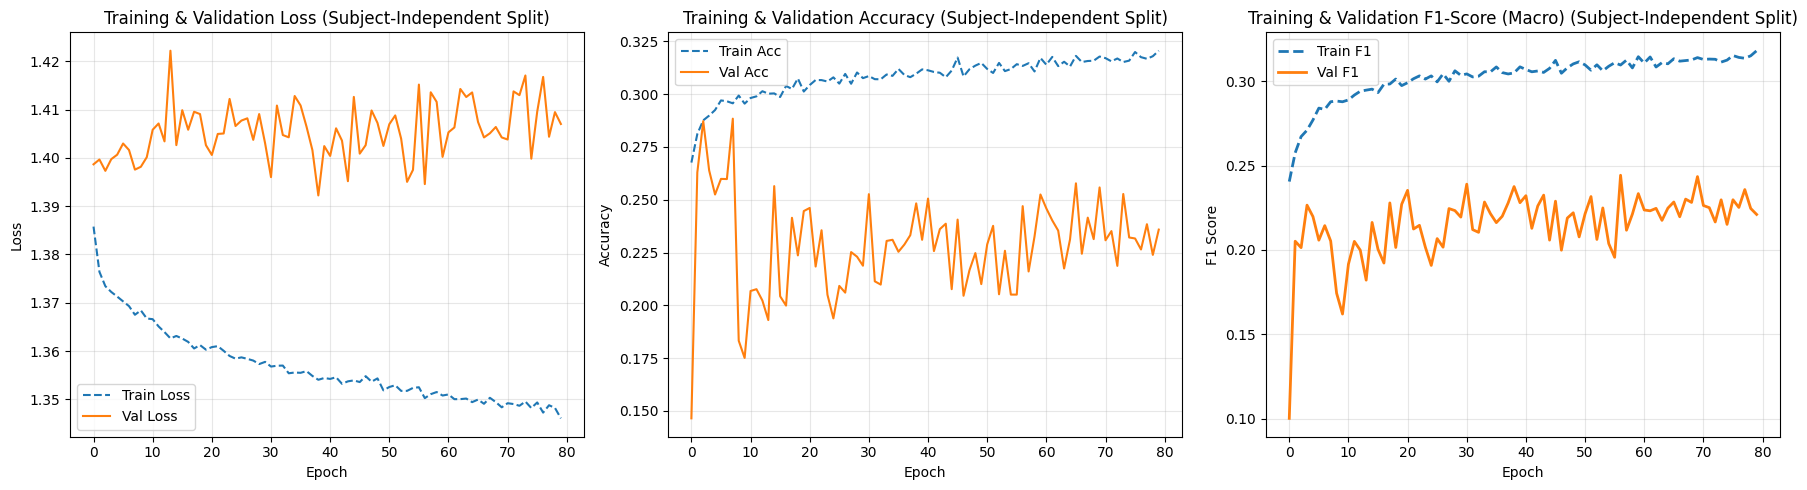


Đánh giá trên tập TEST:
              precision    recall  f1-score   support

        HAHV     0.1639    0.0093    0.0176      2153
        HALV     0.2000    0.0017    0.0034      3511
        LAHV     0.2619    0.1541    0.1940      3674
        LALV     0.3189    0.7935    0.4550      4721

    accuracy                         0.3086     14059
   macro avg     0.2362    0.2396    0.1675     14059
weighted avg     0.2506    0.3086    0.2070     14059

Đã lưu Confusion Matrix tại: /content/drive/MyDrive/AFFEC/results_felt_new/comparison_analysis/confusion_matrix_fau_fusion.png


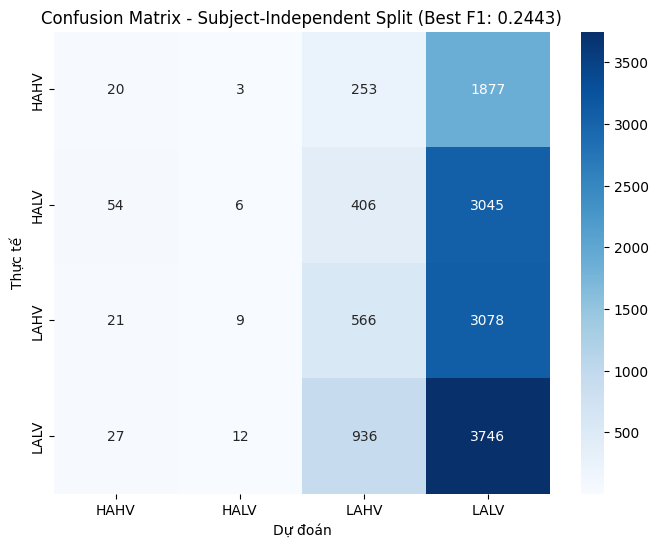

In [ ]:
if __name__ == "__main__":
    train_model()